In [71]:
%pip install seaborn
import seaborn as sns



In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import  LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
df = pd.read_csv("Diabetes_type2raw.csv")
df_clean=df.copy()
print(df_clean.head(10))
df_clean.drop(["Name"], axis=1,inplace=True,errors='ignore')

               Name  Gender  BP(Systolic)  BP(Diastolic) Physical_Activity  \
0     Michael Jones    Male         140.0           90.0               Low   
1      Sandra Green  Female         110.0           80.0               Low   
2    Jennifer Lewis  Female         120.0           80.0            Medium   
3   Ronald Gonzalez    Male         130.0           85.0               Low   
4   Ashley Mitchell  Female         110.0           75.0               Low   
5      Andrew Smith    Male         100.0           80.0              High   
6     Matthew Lewis    Male         110.0           80.0              High   
7      Melissa Hill  Female          90.0           65.0               Low   
8   Patricia Walker  Female         110.0           70.0              High   
9  Joseph Hernandez    Male         140.0           80.0               Low   

    Age        BMI  DiabetesPedigreeFunction  Insulin  Skin Thickness(mm)  \
0  50.0  22.263762                       0.0     92.3           

In [73]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    1019 non-null   object 
 1   BP(Systolic)              1007 non-null   float64
 2   BP(Diastolic)             994 non-null    float64
 3   Physical_Activity         1019 non-null   object 
 4   Age                       998 non-null    float64
 5   BMI                       988 non-null    float64
 6   DiabetesPedigreeFunction  1016 non-null   float64
 7   Insulin                   1058 non-null   float64
 8   Skin Thickness(mm)        984 non-null    float64
 9   Glucose                   992 non-null    float64
 10  Type 2 Diabetes           1065 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 83.3+ KB


In [74]:
df_clean.describe()

,BP(Systolic),BP(Diastolic),Age,BMI,DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Glucose,Type 2 Diabetes
count,1007.000000,994.000000,998.000000,988.000000,1016.000000,1058.000000,984.000000,992.000000,1065.000000
mean,119.520357,79.377264,44.600200,25.252245,1.497047,131.624953,307.443252,137.930544,0.507981
std,14.272112,11.865202,12.700685,3.818955,1.568781,76.458035,34.685654,64.395257,0.500171
min,80.000000,0.000000,21.000000,17.183204,0.000000,0.000000,29.210000,50.000000,0.000000
25%,110.000000,70.000000,35.000000,22.650587,0.000000,65.400000,286.385000,80.000000,0.000000
50%,120.000000,80.000000,44.000000,24.603224,1.000000,118.200000,304.800000,128.500000,1.000000
75%,130.000000,80.000000,54.000000,27.492665,2.000000,198.400000,330.200000,177.250000,1.000000
max,180.000000,120.000000,86.000000,37.442807,8.000000,274.800000,406.400000,450.000000,1.000000


In [75]:
print((df_clean == 0).sum())

Gender                        0
BP(Systolic)                  0
BP(Diastolic)                 4
Physical_Activity             0
Age                           0
BMI                           0
DiabetesPedigreeFunction    357
Insulin                      39
Skin Thickness(mm)            0
Glucose                       0
Type 2 Diabetes             524
dtype: int64


In [76]:
print(df_clean.isnull().sum())

Gender                      46
BP(Systolic)                58
BP(Diastolic)               71
Physical_Activity           46
Age                         67
BMI                         77
DiabetesPedigreeFunction    49
Insulin                      7
Skin Thickness(mm)          81
Glucose                     73
Type 2 Diabetes              0
dtype: int64


In [77]:
categorical_cols = ["Gender", "Physical_Activity"]

for col in categorical_cols:
    col_mode = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(col_mode)
print(df_clean[categorical_cols])

      Gender Physical_Activity
0       Male               Low
1     Female               Low
2     Female            Medium
3       Male               Low
4     Female               Low
...      ...               ...
1060    Male               Low
1061    Male               Low
1062  Female              High
1063  Female            Medium
1064    Male            Medium

[1065 rows x 2 columns]


In [78]:
for column in categorical_cols :
    le = LabelEncoder()
    df_clean[column] = le.fit_transform(df_clean[column])
    
print(df_clean.head(10))

   Gender  BP(Systolic)  BP(Diastolic)  Physical_Activity   Age        BMI  \
0       1         140.0           90.0                  1  50.0  22.263762   
1       0         110.0           80.0                  1  40.0  24.111159   
2       0         120.0           80.0                  2  21.0  17.183204   
3       1         130.0           85.0                  1  30.0  21.244332   
4       0         110.0           75.0                  1  35.0  22.819490   
5       1         100.0           80.0                  0  40.0  24.972272   
6       1         110.0           80.0                  0  55.0  29.289552   
7       0          90.0           65.0                  1  86.0  24.603224   
8       0         110.0           70.0                  0   NaN  23.680603   
9       1         140.0           80.0                  1   NaN  32.722288   

   DiabetesPedigreeFunction  Insulin  Skin Thickness(mm)  Glucose  \
0                       0.0     92.3              317.50    146.0   
1  

In [79]:
cols_zero_invalid = ["Glucose","BMI","Insulin","Skin Thickness(mm)"]
df_clean[cols_zero_invalid] = df_clean[cols_zero_invalid].replace(0, np.nan)

df_clean.loc[df_clean["BP(Systolic)"] < 70, "BP(Systolic)"] = np.nan

df_clean.loc[df_clean["BP(Diastolic)"] < 40, "BP(Diastolic)"] = np.nan

for col in ["BP(Systolic)","BP(Diastolic)","Age","BMI","DiabetesPedigreeFunction",
            "Skin Thickness(mm)","Insulin","Glucose"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print(df_clean)

      Gender  BP(Systolic)  BP(Diastolic)  Physical_Activity   Age        BMI  \
0          1         140.0           90.0                  1  50.0  22.263762   
1          0         110.0           80.0                  1  40.0  24.111159   
2          0         120.0           80.0                  2  21.0  17.183204   
3          1         130.0           85.0                  1  30.0  21.244332   
4          0         110.0           75.0                  1  35.0  22.819490   
...      ...           ...            ...                ...   ...        ...   
1060       1         120.0           70.0                  1  38.0  22.388934   
1061       1         120.0           80.0                  1  47.0  25.833385   
1062       0         100.0           70.0                  0  50.0  24.972272   
1063       0         120.0           80.0                  2  40.0  24.603224   
1064       1         110.0           60.0                  2  55.0  23.680603   

      DiabetesPedigreeFunct

In [80]:
print(df_clean.isnull().sum())

Gender                      0
BP(Systolic)                0
BP(Diastolic)               0
Physical_Activity           0
Age                         0
BMI                         0
DiabetesPedigreeFunction    0
Insulin                     0
Skin Thickness(mm)          0
Glucose                     0
Type 2 Diabetes             0
dtype: int64


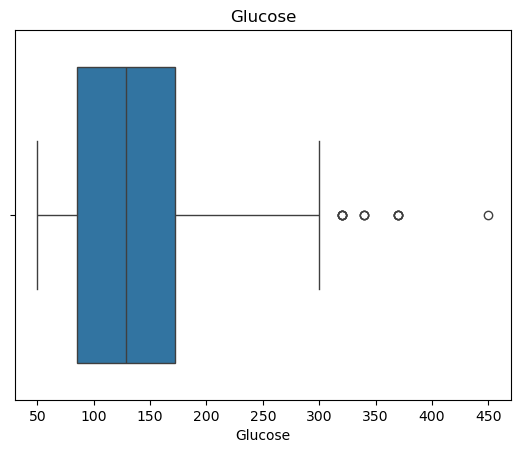

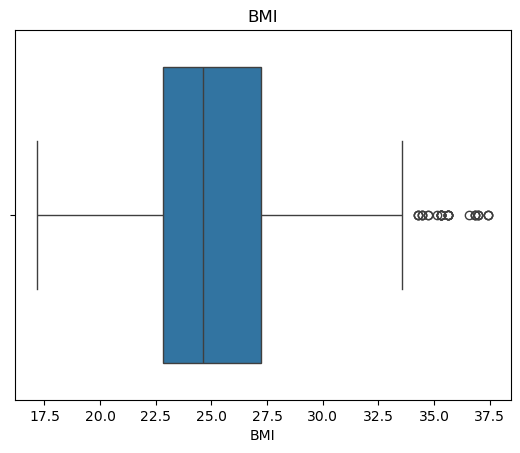

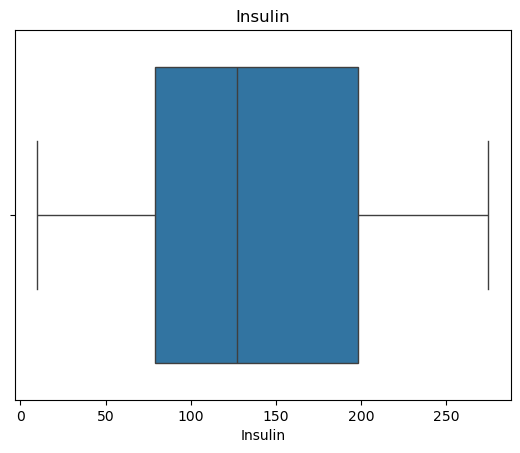

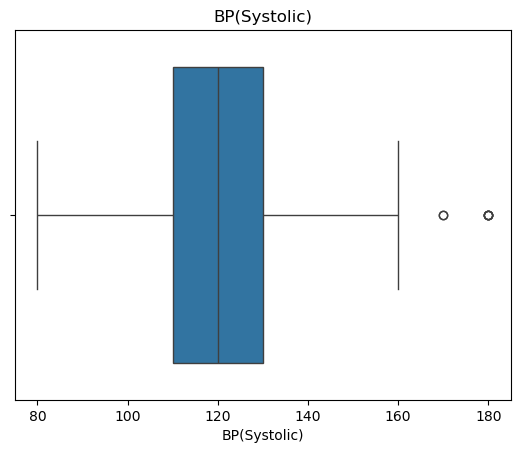

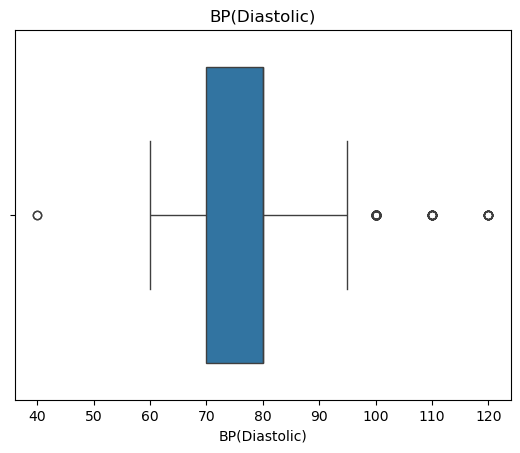

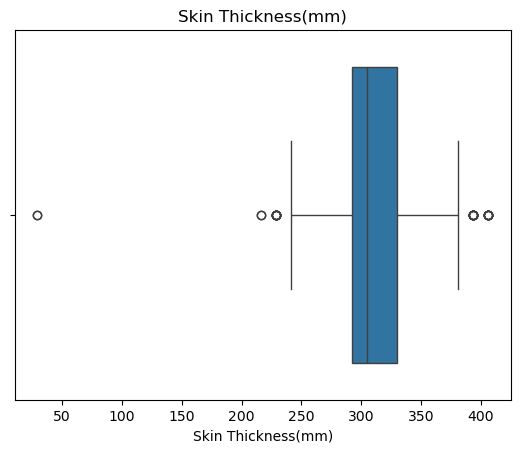

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["Glucose","BMI","Insulin","BP(Systolic)","BP(Diastolic)","Skin Thickness(mm)"]

for col in cols:
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()


In [82]:
cols_to_check = [  "Insulin","BP(Systolic)","BP(Diastolic)"]
print(f"shape before removing outliers of dataset: {df_clean.shape}")
for col in cols_to_check:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"Removing {outliers_count} outliers from {col}")
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

df_clean = df_clean.reset_index(drop=True)
print("\nCleaning complete.")
print(f"shape after removing outliers of dataset: {df_clean.shape}")

shape before removing outliers of dataset: (1065, 11)
Removing 0 outliers from Insulin
Removing 7 outliers from BP(Systolic)
Removing 69 outliers from BP(Diastolic)

Cleaning complete.
shape after removing outliers of dataset: (989, 11)


array([[<Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'BP(Systolic)'}>,
        <Axes: title={'center': 'BP(Diastolic)'}>],
       [<Axes: title={'center': 'Physical_Activity'}>,
        <Axes: title={'center': 'Age'}>, <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'Skin Thickness(mm)'}>],
       [<Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'Type 2 Diabetes'}>, <Axes: >]],
      dtype=object)

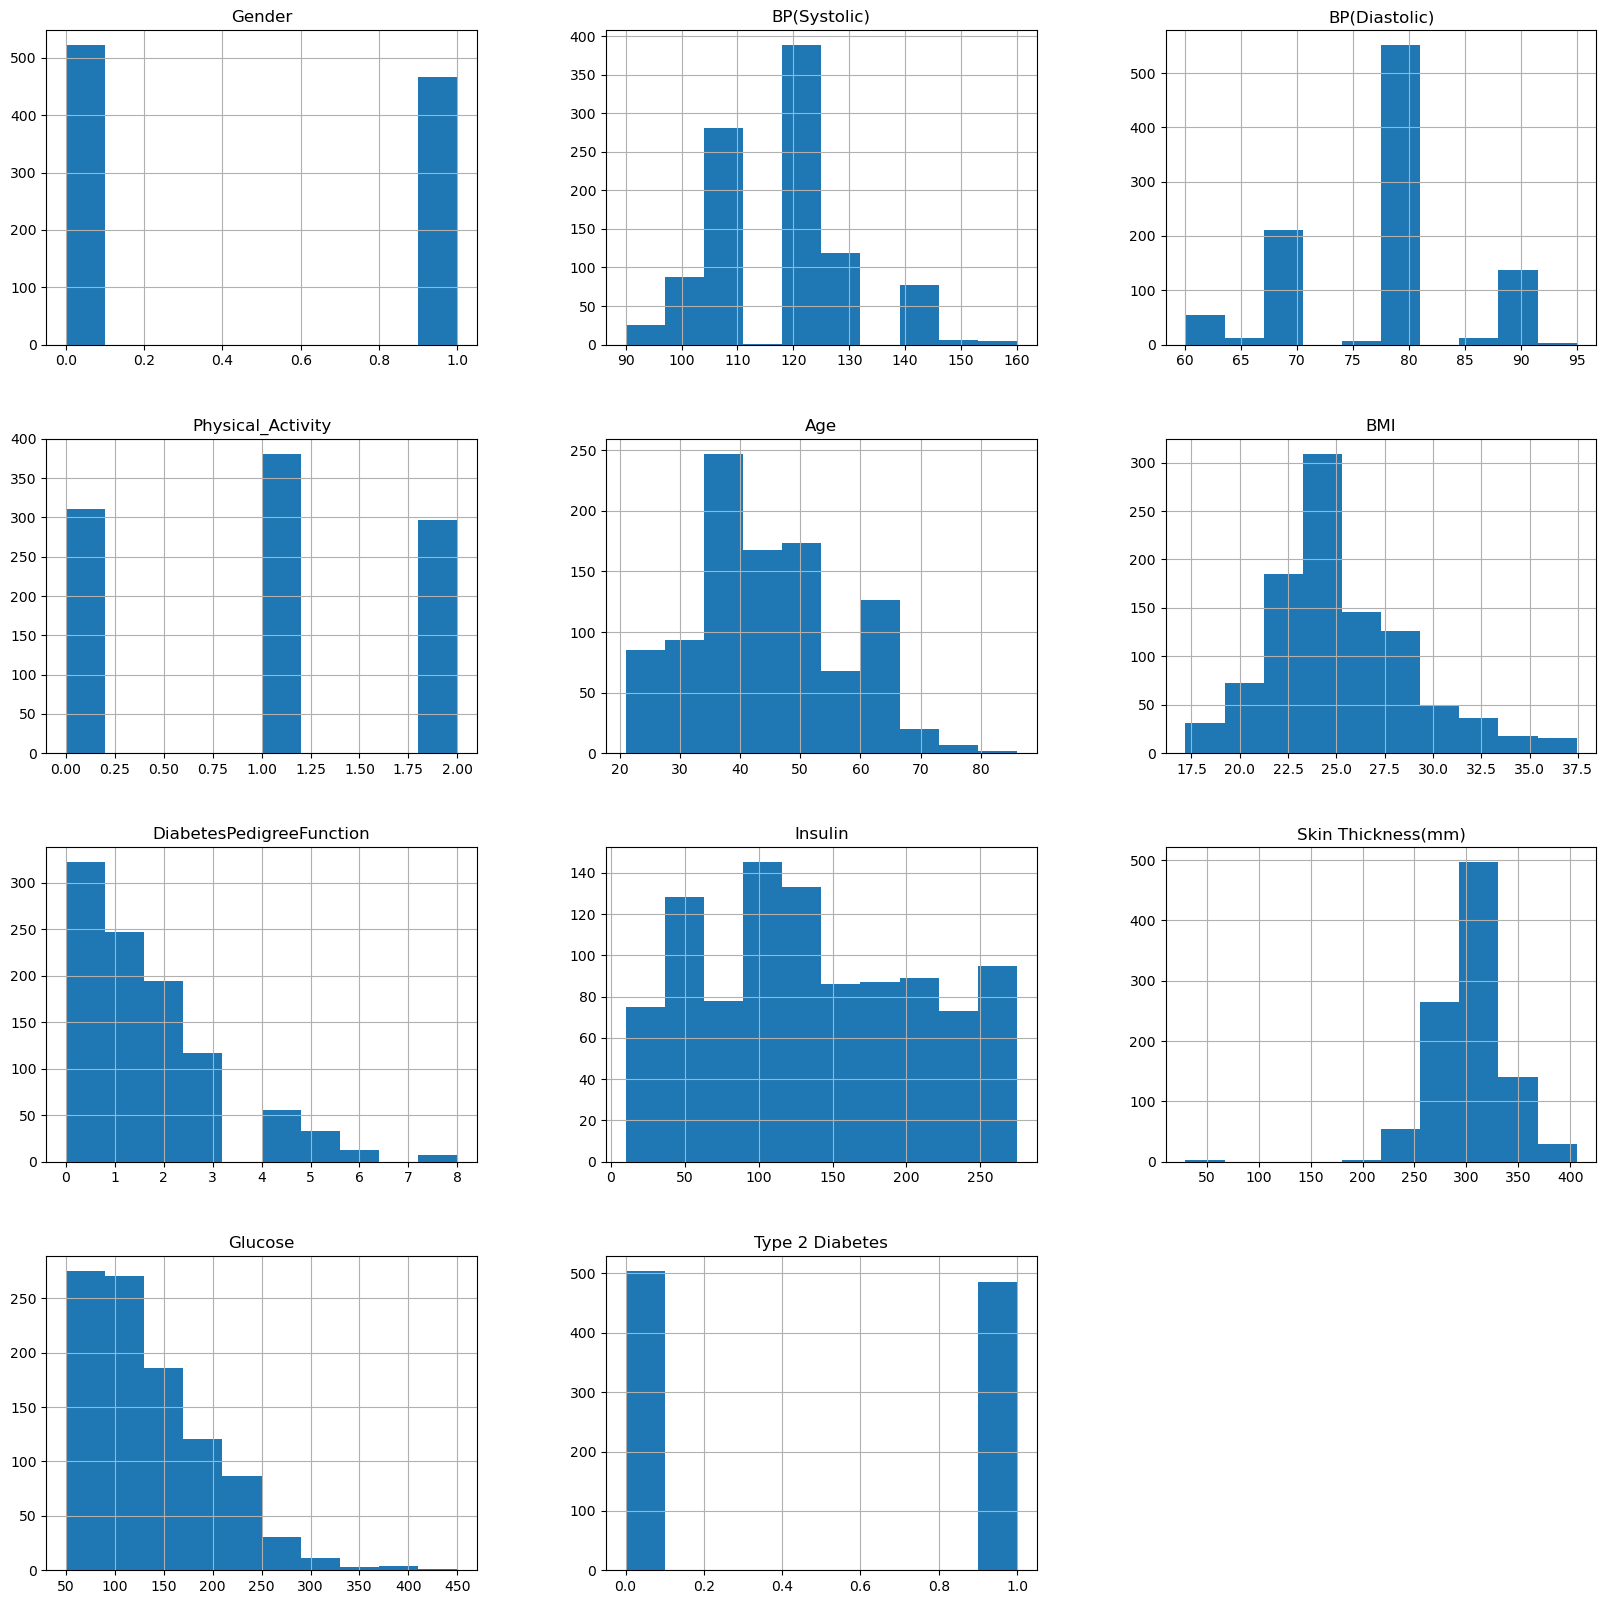

In [83]:
df_clean.hist(figsize=(20,20))

Type 2 Diabetes             1.000000
Glucose                     0.770661
Age                         0.152415
Skin Thickness(mm)          0.117349
BMI                         0.036506
BP(Systolic)                0.035508
DiabetesPedigreeFunction    0.007767
BP(Diastolic)               0.001489
Physical_Activity          -0.005507
Gender                     -0.056778
Insulin                    -0.063699
Name: Type 2 Diabetes, dtype: float64


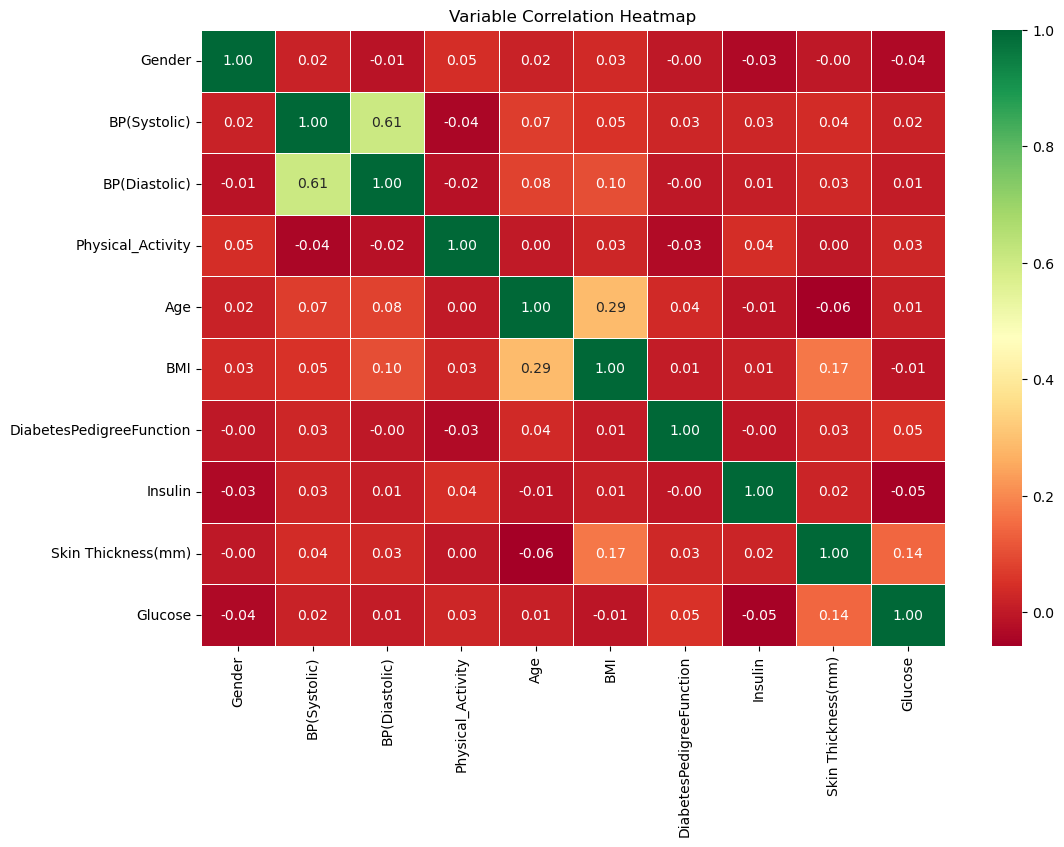

In [84]:
df_co = df_clean.drop('Type 2 Diabetes', axis=1)
correlation_matrix_graph = df_co.corr(numeric_only=True)
correlation_matrix = df_clean.corr(numeric_only=True)
target_corr = correlation_matrix['Type 2 Diabetes'].sort_values(ascending=False)
print(target_corr)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_graph, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Variable Correlation Heatmap")
plt.show()
important_features = target_corr[(target_corr) > 0.1]

In [85]:
print("important_features:\n")
print(important_features)

important_features:

Type 2 Diabetes       1.000000
Glucose               0.770661
Age                   0.152415
Skin Thickness(mm)    0.117349
Name: Type 2 Diabetes, dtype: float64
